In [19]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
subjoin_df = pd.read_pickle('2023-03-24_NB1_subjoin_df.part4.pkl')

In [21]:
uni_auth = np.unique(np.concatenate(np.asarray(subjoin_df.iloc[:, 1:])))

In [22]:
uni_df = pd.DataFrame({'AuthorName': uni_auth})

In [23]:
uni_df

,AuthorName
0,a a petrov
1,a aatiq
2,a abascalsaiz
3,a abate
4,a abbas
...,...
18231,zy xia
18232,zy xiao
18233,zy zhan
18234,zz dai


In [24]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Initiate 
bagofwords = CountVectorizer(stop_words = 'english')

bagofwords.fit(uni_df['AuthorName'])

small_transformed = bagofwords.transform(uni_df['AuthorName'])

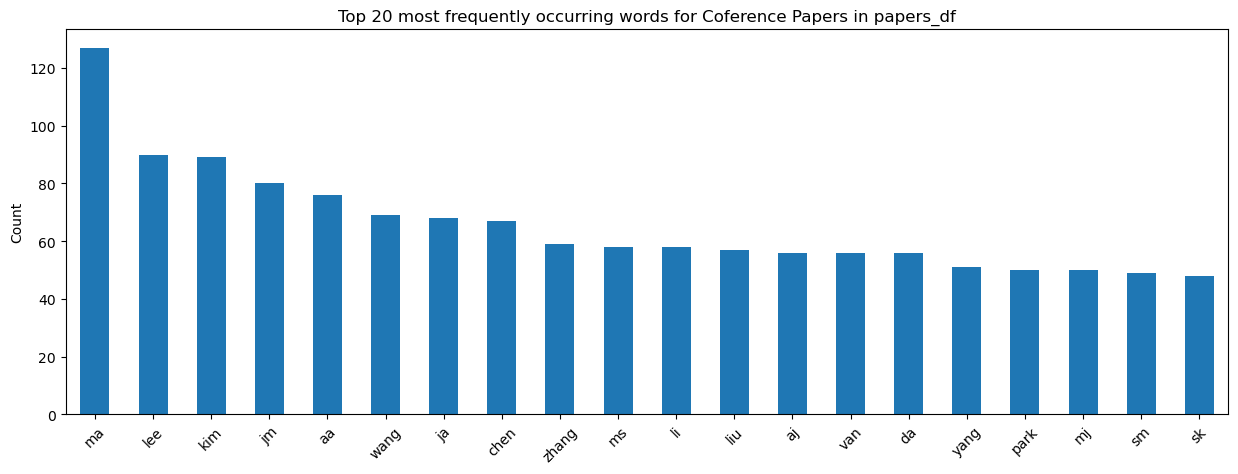

In [25]:
word_counts = pd.DataFrame(
    {"counts": small_transformed.toarray().sum(axis=0)},
    index=bagofwords.get_feature_names_out()
).sort_values("counts", ascending=False)

word_counts.head(20).plot(kind="bar", figsize=(15, 5), legend=False)
plt.title("Top 20 most frequently occurring words for Coference Papers in papers_df")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [16]:
bagofwords.get_feature_names_out().shape

(13388,)

In [26]:
vect_df = pd.DataFrame(small_transformed.toarray(),  columns = bagofwords.get_feature_names_out()).astype('int8')

In [27]:
vect_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18236 entries, 0 to 18235
Columns: 13388 entries, aa to zz
dtypes: int8(13388)
memory usage: 232.8 MB


In [29]:
idx = np.random.randint(0, 18235, 183)

In [34]:
sub_df = vect_df.iloc[idx, 1:]

kmeans = KMeans(n_clusters=20)

kmeans.fit(sub_df)

sub_df['Cluster'] = kmeans.labels_

In [38]:
con_df = pd.concat([uni_df.loc[idx], sub_df['Cluster']], axis = 1)

In [43]:
for name, group in con_df.groupby('Cluster'):
        print(group)

           AuthorName  Cluster
9330         l huerta        0
347           a faika        0
14367         s chang        0
15115        s stuard        0
15296  sa pozdnyakova        0
...               ...      ...
7602        j schacht        0
1132       a verykios        0
8128       jl frieiro        0
10522      m massetti        0
15210          s wood        0

[156 rows x 2 columns]
         AuthorName  Cluster
1741  antonio abate        1
      AuthorName  Cluster
15639     sm lee        2
9129      kt lee        2
      AuthorName  Cluster
17917   yo yayak        3
     AuthorName  Cluster
4182   dn tawse        4
4182   dn tawse        4
      AuthorName  Cluster
5357  fm peeters        5
     AuthorName  Cluster
6600    hq ling        6
      AuthorName  Cluster
9815  lv adamova        7
9817    lv frias        7
      AuthorName  Cluster
13192   pp zhang        8
18174   zh zhang        8
     AuthorName  Cluster
9081  kr carter        9
     AuthorName  Cluster
8954  kd

KeyError: 'Column not found: 0'